# Veri Görselleştirme

## Amaç:
  1. Veri setindeki farklı değişkenleri uygun grafik türleri ile görselleştirme
  2. Grafikler üzerinden zaman değişimi, ilişki, karşılaştırma ve dağılım inceleme

## Adımlar:
  1. Veri setini yükle
  2. Line plot ile zaman içerisinde ki değişimi görselleştir
  3. Scatter plot ile iki sayısal değişken arasındaki ilişkiyi görselleştirme
  4. Bar plot ile karşılaştırmalı görselleştirme yapmak
  5. Histogram ile dağılım analizi
  6. Box plot ile aykırı değer tespiti

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# 1. Veri setini yükle
df = pd.read_csv("e_ticaret_veri_seti_aykiri_degerler_duzenlendi.csv")

In [6]:
df["siparis_tarihi"] = pd.to_datetime(df["siparis_tarihi"])
df["siparis_ayi"] = df["siparis_tarihi"].dt.month


In [10]:
aylik_toplam_tutar = df.groupby("siparis_ayi")["toplam_tutar"].sum().reset_index()
aylik_toplam_tutar

,siparis_ayi,toplam_tutar
0,1,81122.86
1,2,74048.90
2,3,78418.68
3,4,76862.50
4,5,93420.36
5,6,85628.94
6,7,73457.11
7,8,64133.34
8,9,85483.79
9,10,71982.43


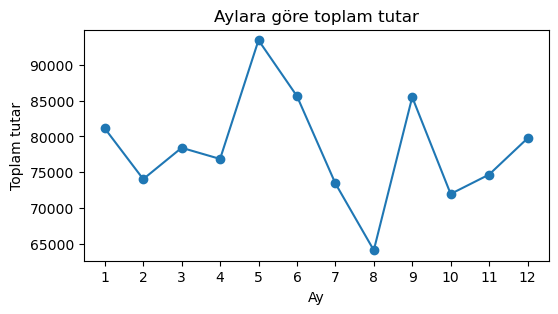

In [12]:
plt.figure(figsize = (6, 3))
plt.plot(aylik_toplam_tutar["siparis_ayi"], aylik_toplam_tutar["toplam_tutar"], marker = "o")
plt.title("Aylara göre toplam tutar")
plt.xlabel("Ay")
plt.ylabel("Toplam tutar")
plt.xticks(aylik_toplam_tutar["siparis_ayi"])
plt.show()

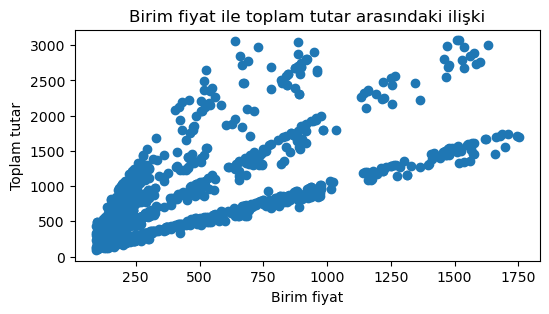

In [14]:
# 3. Scatter Plot
plt.figure(figsize = (6,3))
plt.scatter(df["birim_fiyat"], df["toplam_tutar"])
plt.title("Birim fiyat ile toplam tutar arasındaki ilişki")
plt.xlabel("Birim fiyat")
plt.ylabel("Toplam tutar")
plt.show()

In [16]:
# 4. Bar plot
kategori_toplam_tutar = (
    df.groupby("kategori")["toplam_tutar"]
    .sum()
    .sort_values(ascending = False)
    .reset_index()
)
kategori_toplam_tutar

,kategori,toplam_tutar
0,Elektronik,243084.26
1,Spor,214372.56
2,Kozmetik,160225.69
3,Ev Yaşam,151605.73
4,Kitap,118439.83
5,Ofis,51252.50


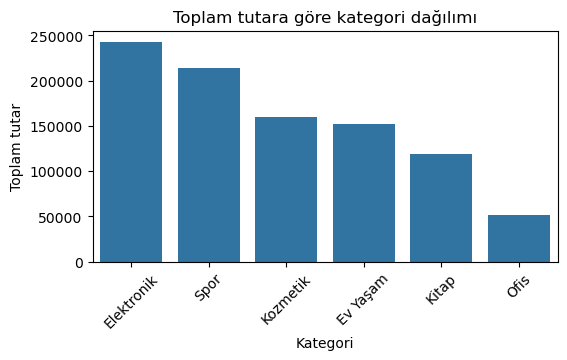

In [18]:
plt.figure(figsize = (6,3))
sns.barplot(data = kategori_toplam_tutar, x = "kategori", y = "toplam_tutar")
plt.title("Toplam tutara göre kategori dağılımı")
plt.xlabel("Kategori")
plt.ylabel("Toplam tutar")
plt.xticks(rotation = 45)
plt.show()

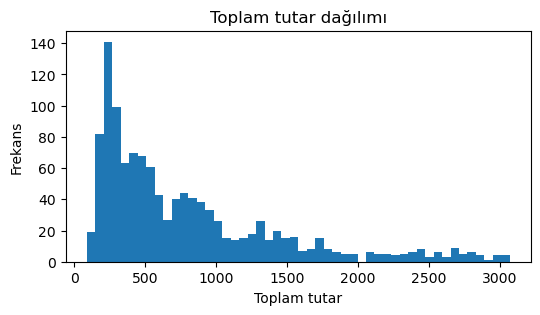

In [20]:
# 5. Histogram
plt.figure(figsize = (6,3))
plt.hist(df["toplam_tutar"], bins = 50)
plt.title("Toplam tutar dağılımı")
plt.xlabel("Toplam tutar")
plt.ylabel("Frekans")
plt.show()

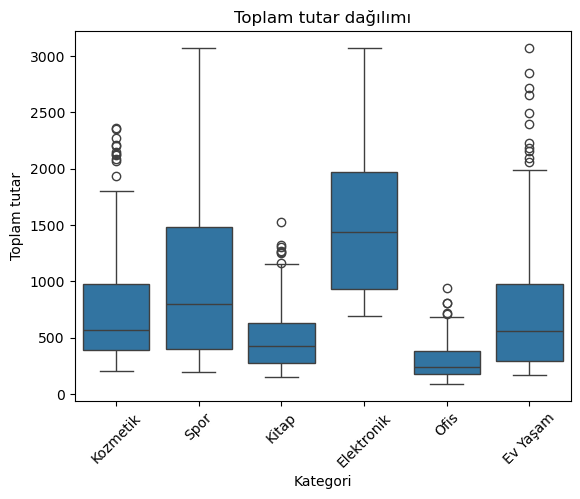

In [22]:
# Box Plot
plt.figure()
sns.boxplot(data = df, x = "kategori", y = "toplam_tutar")
plt.title("Toplam tutar dağılımı")
plt.xlabel("Kategori")
plt.ylabel("Toplam tutar")
plt.xticks(rotation = 45)
plt.show()

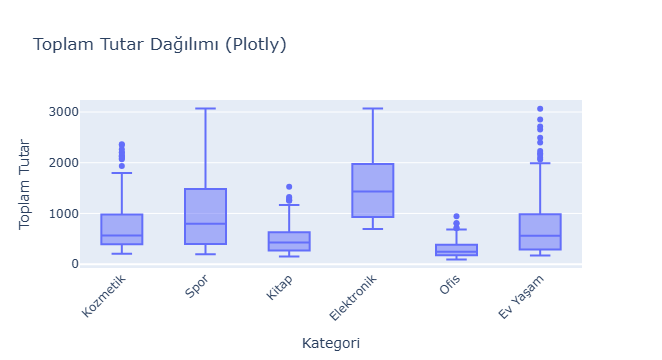

In [24]:
import plotly.express as px

fig = px.box(df, x="kategori", y="toplam_tutar",
             title="Toplam Tutar Dağılımı (Plotly)",
             labels={"kategori": "Kategori", "toplam_tutar": "Toplam Tutar"})

fig.update_layout(xaxis_tickangle=-45)
fig.show()

In [26]:
# Plotly grafiğini HTML olarak kaydet
fig.write_html("toplam_tutar_dagilimi_plotly.html")
print("Grafik 'toplam_tutar_dagilimi_plotly.html' olarak kaydedildi.")

Grafik 'toplam_tutar_dagilimi_plotly.html' olarak kaydedildi.
